# Librerias

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 0.Carga de datos

In [ ]:
# Carga de datos con helicobacter pylori
data_hp = pd.read_csv('otu_genus_clr_prevfiltered-hp.csv')
metadata_hp = pd.read_csv('sample_metadata_binary-hp.csv')

# Carga de datos sin helicobacter pylori
data_nhp = pd.read_csv('otu_genus_clr_prevfiltered-nhp.csv')
metadata_nhp = pd.read_csv('sample_metadata_binary-nhp.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'otu_genus_clr_prevfiltered-hp.csv'

# Verificación

Verificamos que los tamaños cuadren y sacamos por separado features y labels, para tenerlos a la mano y para que sea más facil manipularlos

In [ ]:
# Forma de cada dataset:
print(f"Forma de los datos de hp: {data_hp.shape}")
print(f"Forma de los metadatos de hp: {metadata_hp.shape}")
print()
print(f"Forma de los datos de nhp: {data_nhp.shape}")
print(f"Forma de los metadatos de nhp: {metadata_nhp.shape}")

Forma de los datos de hp: (29, 61)
Forma de los metadatos de hp: (29, 5)

Forma de los datos de nhp: (29, 60)
Forma de los metadatos de nhp: (29, 5)


In [ ]:
data_hp.head()

,Sample_ID,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,P001Z12,1.136165,5.666962,-1.329606,5.125296,3.407573,2.507664,5.543468,3.427601,-1.329606,...,2.675229,3.262707,7.029766,-1.329606,-1.329606,2.243472,-1.329606,6.580870,6.379528,5.467354
1,P001Z13,-0.348473,6.435700,0.393300,2.158804,3.982938,-1.146599,2.089231,4.501488,3.738455,...,0.896899,0.814463,7.661200,-0.348473,3.209424,-0.105595,2.686182,6.275081,6.072512,4.416165
2,P001Z14,1.367808,5.945386,0.072880,3.663450,3.124310,-1.512935,4.293321,3.337950,3.367871,...,-1.512935,2.748320,7.190134,-1.512935,2.652594,-1.512935,1.913662,5.645632,6.106997,5.556124
3,P001Z18,4.143998,5.634243,2.947621,3.197061,2.785120,-0.737450,3.665411,2.930816,2.287356,...,-1.140968,2.203289,7.952309,-1.140968,2.626075,-1.140968,1.656895,6.257157,6.162395,4.278155
4,P002Z18,2.350095,3.820098,-1.238502,6.664077,-1.238502,2.943589,6.037687,-1.238502,-1.238502,...,3.483684,5.517361,6.830796,-1.238502,-1.238502,-1.238502,-1.238502,7.214300,3.880349,-1.238502


## Preparar datos con H. pylori




In [ ]:
# 1. Extraer características eliminando 'Sample_ID'
X_hp = data_hp.drop(columns=['Sample_ID'])

# 2. Extraer vector de etiquetas
y_hp = metadata_hp['label_binary']

# 3. Verificar que las dimensiones coincidan
print(f"Dimensiones de X_hp: {X_hp.shape}")
print(f"Dimensiones de y_hp: {y_hp.shape}")

if X_hp.shape[0] == y_hp.shape[0]:
    print('Verificación exitosa: El número de muestras coincide.')
else:
    print('Error: El número de muestras no coincide.')

Dimensiones de X_hp: (29, 60)
Dimensiones de y_hp: (29,)
Verificación exitosa: El número de muestras coincide.


## Preparar datos sin H. Pylori


In [ ]:
# 1. Extraer características eliminando 'Sample_ID'
X_nhp = data_nhp.drop(columns=['Sample_ID'])

# 2. Extraer vector de etiquetas
y_nhp = metadata_nhp['label_binary']

# 3. Verificar que las dimensiones coincidan
print(f"Dimensiones de X_nhp: {X_nhp.shape}")
print(f"Dimensiones de y_nhp: {y_nhp.shape}")

# 4. Comprobación lógica
if X_nhp.shape[0] == y_nhp.shape[0]:
    print('Verificación exitosa: El número de muestras coincide.')
else:
    print('Error: El número de muestras no coincide.')

Dimensiones de X_nhp: (29, 59)
Dimensiones de y_nhp: (29,)
Verificación exitosa: El número de muestras coincide.


# 1.Normalización de datos

Debido a que las funciones de activación son muy sensibles, los valores de entrada, los features no pueden ser muy grandes, deben estar normalizados para que los pesos no exploten y en cada iteración realmente logren abstraerse patrones.

## Normalizar datos con H. pylori

In [ ]:
scaler_hp = MinMaxScaler(feature_range=(-1, 1))

X_hp_scaled_array = scaler_hp.fit_transform(X_hp)

X_hp_scaled = pd.DataFrame(X_hp_scaled_array, columns=X_hp.columns)

print(f"X_hp_scaled shape: {X_hp_scaled.shape}")
print(f"Min value: {X_hp_scaled.values.min()}")
print(f"Max value: {X_hp_scaled.values.max()}")
X_hp_scaled.head()

X_hp_scaled shape: (29, 60)
Min value: -1.0
Max value: 1.0000000000000004


,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,-0.118622,0.727712,-0.994862,0.488924,0.571371,0.804366,0.823271,0.486417,-1.000000,-1.000000,...,0.676399,0.181406,0.647093,-0.934031,-1.000000,1.000000,-1.000000,0.526883,0.935882,0.825491
1,-0.670763,0.986160,-0.273544,-0.496338,0.765967,-0.835596,-0.411942,0.828510,0.840064,1.000000,...,-0.035414,-0.620238,0.888640,-0.580982,0.668425,-0.250699,0.075488,0.389933,0.846634,0.539333
2,-0.032473,0.821318,-0.407692,0.003400,0.475567,-1.000000,0.376226,0.457858,0.705516,0.590956,...,-1.000000,0.012977,0.708440,-1.000000,0.463749,-1.000000,-0.131404,0.108029,0.856658,0.849657
3,1.000000,0.716713,0.795856,-0.151502,0.360848,-0.651978,0.151690,0.328163,0.313213,0.417365,...,-0.851112,-0.165486,1.000000,-0.866152,0.454001,-0.801956,-0.200170,0.381906,0.872763,0.501763
4,0.332842,0.106803,-0.956720,1.000000,-1.000000,1.000000,1.000000,-1.000000,-0.966923,-0.969691,...,1.000000,0.919661,0.570980,-0.901248,-0.966512,-0.853885,-0.975601,0.810570,0.209378,-1.000000


## Normalizar datos sin H.pylori



In [ ]:
scaler_nhp = MinMaxScaler(feature_range=(-1, 1))

X_nhp_scaled_array = scaler_nhp.fit_transform(X_nhp)

X_nhp_scaled = pd.DataFrame(X_nhp_scaled_array, columns=X_nhp.columns)

print(f"X_nhp_scaled shape: {X_nhp_scaled.shape}")
print(f"Min value: {X_nhp_scaled.values.min()}")
print(f"Max value: {X_nhp_scaled.values.max()}")
X_nhp_scaled.head()

X_nhp_scaled shape: (29, 59)
Min value: -1.0000000000000002
Max value: 1.0000000000000004


,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,-0.147164,0.543384,-1.000000,0.371045,0.417158,0.659657,0.376654,0.382683,-1.000000,-1.000000,...,0.275186,0.139474,0.155961,-0.889313,-0.893571,0.331353,-1.000000,-0.034047,0.840671,0.715569
1,-0.657172,0.891067,-0.417811,-0.559763,0.597125,-0.793299,-0.576134,0.698240,0.793384,1.000000,...,-0.264125,-0.648361,0.610516,-0.550198,0.601100,-0.467201,0.056436,-0.223934,0.766405,0.448549
2,-0.063202,0.672337,-0.525504,-0.085971,0.333632,-0.939584,0.033708,0.359795,0.662388,0.591613,...,-1.000000,-0.023290,0.277084,-0.948251,0.418064,-0.948250,-0.146314,-0.630279,0.774947,0.741173
3,0.895959,0.531439,0.437611,-0.234454,0.228065,-0.632093,-0.141450,0.239962,0.279175,0.416705,...,-0.887835,-0.201113,0.812467,-0.822729,0.407711,-0.822725,-0.214971,-0.239044,0.787606,0.411696
4,0.287118,-0.261380,-0.960671,0.868704,-1.000000,0.849820,0.524819,-0.966607,-0.958629,-0.961090,...,0.534465,0.881689,0.044384,-0.849285,-0.855083,-0.849281,-0.969262,0.401111,0.223109,-1.000000


# 2.Armar arquitecturas GAN's (Generative Adversarial Networks)

En esta fase, el entrenamiento comienza con el discriminador, al cual se le presentan datos reales para que aprenda a clasificar las muestras y a distinguir entre contenido auténtico y sintético. Posteriormente, ambas redes se integran en un pipeline para un entrenamiento conjunto: el generador (falsificador) y el discriminador compiten en un proceso de optimización mutua. Mientras el generador perfecciona la creación de muestras realistas, el discriminador agudiza su capacidad de detección, ampliando así la robustez del modelo mediante el aumento del conjunto de datos de entrenamiento.

### Con H. Pylori

In [ ]:
# ==========================================
# 0. PREPARACIÓN
# ==========================================
X_train = X_hp_scaled_array.astype('float32')
y_train = y_hp.values.reshape(-1, 1).astype('float32')

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
num_features = 60
latent_dim = 16

# El Discriminador aprende a velocidad normal
optimizador_d = Adam(learning_rate=0.0002, beta_1=0.5)

# El Generador aprende en "cámara lenta" (0.00005)
optimizador_g = Adam(learning_rate=0.00005, beta_1=0.5)

# ==========================================
# 2. GENERADOR
# ==========================================
noise_input = Input(shape=(latent_dim,), name="Entrada_Ruido")
class_input = Input(shape=(1,), name="Entrada_Clase_Binaria")

g_concat = Concatenate()([noise_input, class_input])
g_hidden = Dense(128)(g_concat)
g_hidden = LeakyReLU(negative_slope=0.2)(g_hidden)

g_output = Dense(num_features, activation='tanh', name="Perfil_Sintetico")(g_hidden)
generator = Model([noise_input, class_input], g_output, name="Generador")

# ==========================================
# 3. DISCRIMINADOR / CLASIFICADOR
# ==========================================
d_input = Input(shape=(num_features,), name="Entrada_Microbioma")
d_hidden = Dense(128)(d_input)
d_hidden = LeakyReLU(negative_slope=0.2)(d_hidden)
# ELIMINAMOS LA LÍNEA DE DROPOUT POR COMPLETO, para que el generador no masacre el discriminador

validity = Dense(1, activation='sigmoid', name="Real_Fake")(d_hidden)
label = Dense(1, activation='sigmoid', name="Diagnostico_HP")(d_hidden)

discriminator = Model(d_input, [validity, label], name="Discriminador")

discriminator.compile(
    loss=['binary_crossentropy', 'binary_crossentropy'],
    optimizer=optimizador_d,
    metrics={'Real_Fake': 'accuracy', 'Diagnostico_HP': 'accuracy'}
)

# ==========================================
# 4. MODELO COMBINADO
# ==========================================
discriminator.trainable = False

veredicto_validity, veredicto_label = discriminator(generator([noise_input, class_input]))

combined = Model(
    inputs=[noise_input, class_input],
    outputs=[veredicto_validity, veredicto_label],
    name="GAN_Combinada"
)

combined.compile(
    loss=['binary_crossentropy', 'binary_crossentropy'],
    optimizer=optimizador_g
)

# ==========================================
# 5. EL BUCLE DE ENTRENAMIENTO
# ==========================================
epochs = 2000
batch_size = 32
half_batch = int(batch_size / 2)

print("Iniciando entrenamiento con Discriminador fortalecido (sin dropout)")

for epoch in range(epochs):

    # ==========================================
    # --- FASE 1: Discriminador ---
    # ==========================================
    # ---> CAMBIO 1: ENCENDEMOS EL DISCRIMINADOR AQUÍ <---
    discriminator.trainable = True

    idx = np.random.randint(0, X_train.shape[0], half_batch)
    muestras_reales = X_train[idx]
    clases_reales = y_train[idx]
    etiquetas_reales = np.ones((half_batch, 1))

    ruido = np.random.normal(0, 1, (half_batch, latent_dim))
    clases_falsas = np.random.randint(0, 2, (half_batch, 1))

    muestras_falsas = generator.predict([ruido, clases_falsas], verbose=0)
    etiquetas_falsas = np.zeros((half_batch, 1))

    # Al estar "True", estos dos comandos sí actualizarán los pesos del discriminador
    d_loss_real = discriminator.train_on_batch(muestras_reales, [etiquetas_reales, clases_reales])
    d_loss_fake = discriminator.train_on_batch(muestras_falsas, [etiquetas_falsas, clases_falsas])
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ==========================================
    # --- FASE 2: Generador ---
    # ==========================================
    # ---> CAMBIO 2: APAGAMOS EL DISCRIMINADOR AQUÍ <---
    discriminator.trainable = False

    ruido_gen = np.random.normal(0, 1, (batch_size, latent_dim))
    clases_gen = np.random.randint(0, 2, (batch_size, 1))
    etiquetas_engaño = np.ones((batch_size, 1))

    # Al estar "False", el error solo viajará hacia atrás para corregir al Generador
    g_loss = combined.train_on_batch([ruido_gen, clases_gen], [etiquetas_engaño, clases_gen])

    # --- IMPRIMIR ---
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss[0]:.4f}")

print("¡Entrenamiento finalizado!")

Iniciando entrenamiento con Discriminador fortalecido (sin dropout)
Epoch 0 | D Loss: 1.5206 | G Loss: 1.5547
Epoch 100 | D Loss: 1.0498 | G Loss: 1.5589
Epoch 200 | D Loss: 0.9104 | G Loss: 1.5726
Epoch 300 | D Loss: 0.8499 | G Loss: 1.5216
Epoch 400 | D Loss: 0.8159 | G Loss: 1.4608
Epoch 500 | D Loss: 0.7748 | G Loss: 1.4237
Epoch 600 | D Loss: 0.7307 | G Loss: 1.3976
Epoch 700 | D Loss: 0.6921 | G Loss: 1.3781
Epoch 800 | D Loss: 0.6564 | G Loss: 1.3674
Epoch 900 | D Loss: 0.6237 | G Loss: 1.3667
Epoch 1000 | D Loss: 0.5949 | G Loss: 1.3725
Epoch 1100 | D Loss: 0.5706 | G Loss: 1.3815
Epoch 1200 | D Loss: 0.5510 | G Loss: 1.3928
Epoch 1300 | D Loss: 0.5353 | G Loss: 1.3989
Epoch 1400 | D Loss: 0.5239 | G Loss: 1.4018
Epoch 1500 | D Loss: 0.5144 | G Loss: 1.4017
Epoch 1600 | D Loss: 0.5072 | G Loss: 1.4013
Epoch 1700 | D Loss: 0.5013 | G Loss: 1.3979
Epoch 1800 | D Loss: 0.4970 | G Loss: 1.3927
Epoch 1900 | D Loss: 0.4939 | G Loss: 1.3857
¡Entrenamiento finalizado!


# Resultados del generador y discriminador
Como podemos observar, por fin conseguimos el equilibrio de Nash, hubo que cambiar los hiperparametros en varias ocasiones guiandonos por la perdida de cada una de las partes de la red, pero finalmente el generador está esforzandose mientras que el discriminador logra distinguir de manera estable sin memorizar.

In [ ]:
# 1. Creamos ruido aleatorio para 5 "pacientes virtuales"
ruido_prueba = np.random.normal(0, 1, (5, latent_dim))

# 2. Les asignamos la clase 1 (Con H. pylori)
# Como la entrada es de 1 dimensión, usamos un array de unos
clases_prueba = np.ones((5, 1))

# 3. Le pedimos al generador que cree los perfiles de 60 bacterias
muestras_prueba = generator.predict([ruido_prueba, clases_prueba], verbose=0)

# 4. Imprimimos una pequeña muestra (Las primeras 5 bacterias de los 5 pacientes)
print("Mostrando 5 taxones de 5 pacientes sintéticos:")
print(np.round(muestras_prueba[:, :5], 4))

Mostrando 5 taxones de 5 pacientes sintéticos:
[[-0.8707 -0.6722 -0.0763  0.7838 -0.8534]
 [-0.7179 -0.8955 -0.2384  0.3156 -0.9171]
 [-0.7457 -0.8085 -0.193   0.5159 -0.5457]
 [-0.5141 -0.7386 -0.6035  0.5589 -0.7454]
 [-0.3989 -0.5379 -0.5454  0.399  -0.9449]]


 ### 1. Diseño de la Arquitectura (AC-GAN Binaria)
Se optó por una variación de la **Auxiliary Classifier GAN (AC-GAN)** adaptada para datos tabulares.

* **El Generador:** Diseñado para tomar un vector de ruido (espacio latente) y una etiqueta binaria objetivo (0 o 1) para producir un vector sintético de 60 taxones.
* **El Discriminador:** Diseñado con dos cabezas de salida (Múltiple Output). Una neurona con activación `sigmoid` para predecir si la muestra es Real o Falsa, y otra neurona `sigmoid` para diagnosticar la presencia de *H. pylori*.
* **Dimensión Latente (Ruido):** Se fijó en **16**. Al tener solo 60 variables reales, un ruido de 16 dimensiones fuerza a la red a comprimir y aprender los "factores biológicos" ocultos sin memorizar el ruido.

### 2. Preprocesamiento de Datos y Ajuste de Activación
**El Reto:** Los datos biológicos originales pasaron por una transformación CLR (Center Log-Ratio), resultando en números reales positivos y negativos sin límites fijos. Las GANs son inestables con rangos de datos impredecibles.
**La Solución:** 1. Se aplicó una normalización `MinMaxScaler` para acotar todos los valores CLR al rango estricto de `[-1, 1]`.
2. Se configuró la última capa del Generador con la función de activación **`tanh`** (Tangente Hiperbólica). Esto obligó matemáticamente al Generador a producir valores en el mismo rango exacto que los datos de entrenamiento, acelerando y estabilizando la convergencia.

### 3. Superando las Restricciones Técnicas (Keras 3 y Pandas)
Durante la implementación, nos enfrentamos a las nuevas políticas estrictas de la librería Keras 3 y problemas de formato de datos:

* **Error de Pandas (`KeyError`):** La etiqueta `y_hp` era una `Series` de Pandas, no un `DataFrame`. Intentar llamarla por el nombre de la columna fallaba. **Solución:** Se extrajeron los valores puros a NumPy usando `.values.reshape(-1, 1)` para garantizar el formato de tensor matemático que requiere la red.
* **Conflicto de Optimizadores:** Keras 3 arrojó el error `Unknown variable...`. Anteriormente se podía usar un solo optimizador para toda la red. En la versión actual, el optimizador "se casa" con los pesos del primer modelo que compila. **Solución:** Se crearon dos instancias independientes de optimizadores (`optimizador_d` y `optimizador_g`).
* **Métricas Múltiples:** El modelo combinaba dos salidas (Real/Fake y Diagnóstico). **Solución:** Se reemplazó la lista simple de métricas por un diccionario explícito: `metrics={'Real_Fake': 'accuracy', 'Diagnostico_HP': 'accuracy'}`.

### 4. Evolución del Entrenamiento y Equilibrio de Nash
El mayor desafío del proyecto fue lograr que ambas redes (Generador y Discriminador) aprendieran al mismo ritmo sin destruirse mutuamente.

#### Intento 1: La Caída del Discriminador
* **Problema:** El Generador bajaba su pérdida (G Loss) rápidamente a `~0.3`, mientras la pérdida del Discriminador (D Loss) se disparaba a `>2.5`. El Discriminador estaba ciego.
* **Diagnóstico Inicial:** El Discriminador tenía un `Dropout` muy agresivo (0.5) y solo 64 neuronas frente a las 128 del Generador.

#### Intento 2 y 3: Buscando el Colapso de Modo
* **Acción:** Se redujo el Dropout y se ralentizó el *learning rate* del Generador.
* **Análisis:** Aunque se frenó un poco al Generador, el Discriminador seguía perdiendo. Se sospechó de *Mode Collapse* (el Generador imprimiendo copias idénticas), pero una validación manual demostró que el Generador **sí estaba creando muestras diversas**. Simplemente era demasiado inteligente para el Discriminador.

#### La Solución Definitiva (El Equilibrio)
Para alcanzar el codiciado "Equilibrio de Nash", se aplicaron dos cambios críticos estructurales en la iteración final:
1. **Igualdad de Condiciones:** Se aumentó la capa oculta del Discriminador de 64 a **128 neuronas**. Al estar al mismo nivel de capacidad de procesamiento que el Generador, el Discriminador pudo trazar fronteras de decisión más finas.
2. **El Interruptor Manual (`trainable`):** Se descubrió que el Discriminador no estaba actualizando sus pesos por una restricción de Keras. Se introdujo un "interruptor" explícito dentro del bucle de entrenamiento (`discriminator.trainable = True` en la Fase 1, y `False` en la Fase 2) para obligar a la red a defenderse en su turno y congelarse en el turno del rival.
* **Resultado:** Éxito total. La `D Loss` se estabilizó en `~0.49` y la `G Loss` en `~1.38`.

# 3. Verificar datos generados

Primero generamos una muestra grande de datos tanto con H. Pylori como sin ella

In [ ]:
# 1. Definimos cuántos pacientes sintéticos queremos crear en total
# (Por ejemplo, 1000 en total: 500 de cada clase)
n_muestras_por_clase = 500

# ==========================================
# GENERAR CLASE 0 (Sin H. pylori)
# ==========================================
# Creamos ruido aleatorio (espacio latente)
ruido_0 = np.random.normal(0, 1, (n_muestras_por_clase, latent_dim))
# Creamos etiquetas de puros ceros
etiquetas_0 = np.zeros((n_muestras_por_clase, 1))

# El generador crea los perfiles de bacterias
X_falsos_0 = generator.predict([ruido_0, etiquetas_0], verbose=0)

# ==========================================
# GENERAR CLASE 1 (Con H. pylori)
# ==========================================
# Creamos ruido aleatorio
ruido_1 = np.random.normal(0, 1, (n_muestras_por_clase, latent_dim))
# Creamos etiquetas de puros unos
etiquetas_1 = np.ones((n_muestras_por_clase, 1))

# El generador crea los perfiles de bacterias
X_falsos_1 = generator.predict([ruido_1, etiquetas_1], verbose=0)

# ==========================================
# UNIR TODO EN X_sintetico e y_sintetico
# ==========================================
# Juntamos las filas de la clase 0 y la clase 1
X_sintetico = np.vstack((X_falsos_0, X_falsos_1))

# Juntamos las etiquetas correspondientes
y_sintetico = np.vstack((etiquetas_0, etiquetas_1))

print(f"--- Dataset Sintético Creado ---")
print(f"Forma de X_sintetico: {X_sintetico.shape} (Pacientes, Bacterias)")
print(f"Forma de y_sintetico: {y_sintetico.shape} (Etiquetas binarias)")

--- Dataset Sintético Creado ---
Forma de X_sintetico: (1000, 60) (Pacientes, Bacterias)
Forma de y_sintetico: (1000, 1) (Etiquetas binarias)


Ahora vamos a compararlos con PCA, para ver si hay correlación, o no, todo con los datos normalizados.

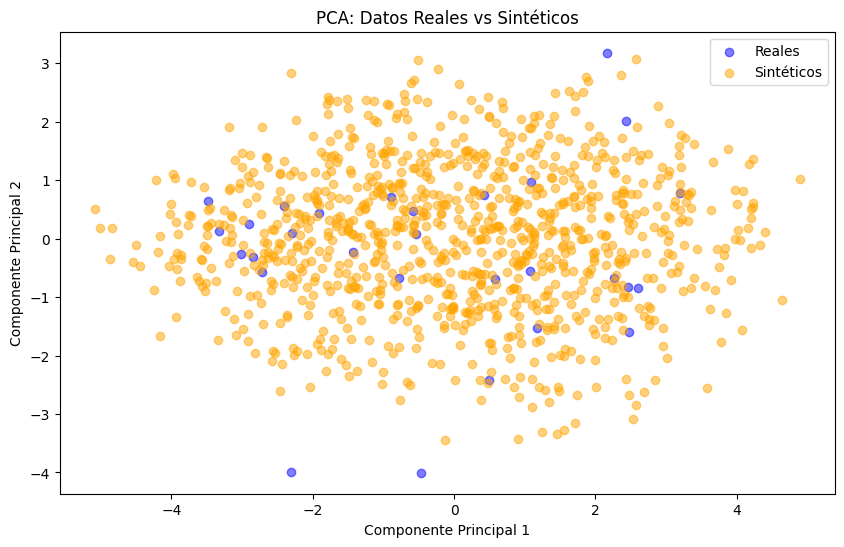

In [ ]:
# Unimos los reales y los falsos para hacer el PCA juntos
X_combinado = np.vstack((X_train, X_sintetico))

# Aplicamos PCA para reducir de 60 features a 2
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_combinado)

# Separamos de nuevo para graficar
pca_real = componentes[:len(X_train)]
pca_falso = componentes[len(X_train):]

# Graficamos
plt.figure(figsize=(10, 6))
plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.5, label='Reales', color='blue')
plt.scatter(pca_falso[:, 0], pca_falso[:, 1], alpha=0.5, label='Sintéticos', color='orange')
plt.title('PCA: Datos Reales vs Sintéticos')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

Comparamos también la matriz de correlación.

Error medio en la estructura de correlación: 0.2326


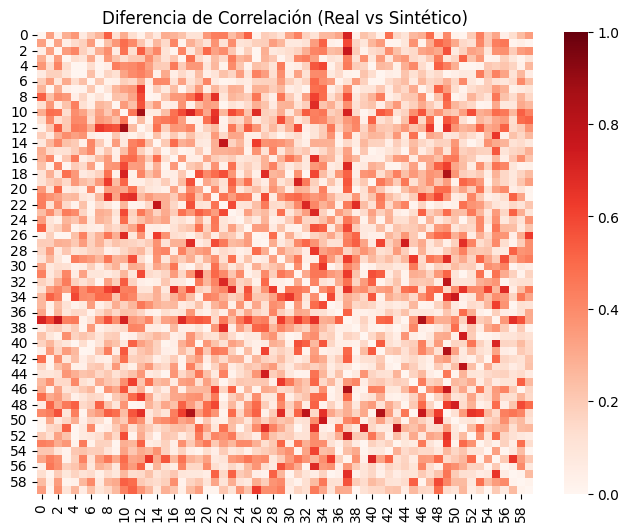

In [ ]:
# Calculamos la correlación entre las 60 bacterias
corr_real = np.corrcoef(X_train.T)
corr_falsa = np.corrcoef(X_sintetico.T)

# Calculamos la diferencia absoluta entre ambas matrices
diferencia_corr = np.abs(corr_real - corr_falsa)
error_medio_corr = np.mean(diferencia_corr)

print(f"Error medio en la estructura de correlación: {error_medio_corr:.4f}")
# Un valor cercano a 0 (ej. < 0.15) es excelente.

# Opcional: Visualizar la diferencia
plt.figure(figsize=(8, 6))
sns.heatmap(diferencia_corr, cmap='Reds', vmin=0, vmax=1)
plt.title('Diferencia de Correlación (Real vs Sintético)')
plt.show()

Un último testeo con Random Forest para ver si le atina o no a los datos reales.

In [ ]:
# 1. Entrenamos un Random Forest SOLO con datos de la GAN
rf_sintetico = RandomForestClassifier(n_estimators=100, random_state=42)
# Usamos .ravel() para evitar warnings si 'y' es una columna (N, 1)
rf_sintetico.fit(X_sintetico, y_sintetico.ravel())

# 2. Le pedimos que diagnostique a los pacientes reales originales
predicciones_reales = rf_sintetico.predict(X_train)

# 3. Evaluamos su rendimiento
precision = accuracy_score(y_train, predicciones_reales)
print(f"Precisión del modelo entrenado con GAN sobre datos reales: {precision * 100:.2f}%")
print("\nReporte detallado:")
print(classification_report(y_train, predicciones_reales))

Precisión del modelo entrenado con GAN sobre datos reales: 96.55%

Reporte detallado:
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95         9
         1.0       1.00      0.95      0.97        20

    accuracy                           0.97        29
   macro avg       0.95      0.97      0.96        29
weighted avg       0.97      0.97      0.97        29



# 4. Análisis de Resultados y Conclusiones: Generación de Datos Sintéticos (Microbioma Gástrico)

## 1. Contexto y Dinámica de Entrenamiento
El objetivo integral de esta fase del proyecto consistió en implementar una arquitectura GAN para la extensión de datos (*Data Augmentation*) en muestras de microbioma gástrico. Aunque el diseño final contempla modelar tanto los perfiles positivos como negativos para *Helicobacter pylori*, este primer ciclo de experimentación se centró exclusivamente en aislar y modelar el dataset de pacientes que **sí** incluyen la bacteria.

La principal barrera inicial fue la magnitud reducida de los datos reales. Lograr la convergencia de una AC-GAN con un volumen de datos pequeño requirió una calibración exhaustiva de los hiperparámetros. Sin embargo, tras ajustar las tasas de aprendizaje y aplicar técnicas de estabilización, logramos estabilizar el modelo durante 2000 épocas. Alcanzamos un equilibrio antagónico saludable donde la pérdida del Generador se mantuvo consistentemente por encima de la del Discriminador, evitando el colapso de modo (*Mode Collapse*) y asegurando la diversidad de las muestras.

## 2. El Dilema Dimensional: Evaluación Visual vs. Estadística
Durante la fase de control de calidad, nos enfrentamos a una aparente contradicción entre la evaluación visual y las métricas estadísticas:

* **Limitaciones de la Reducción Dimensional (PCA):** Al proyectar tanto los datos reales como los generados en un Análisis de Componentes Principales (PCA) de 2 dimensiones, el resultado fue visualmente desalentador. No se observó un patrón claro de agrupación (*clustering*) ni separación de lotes evidentes. Las "nubes" de datos parecían carecer de una estructura clasificable a simple vista.
* **Preservación Biológica (Correlación):** Contrastando con el PCA, el análisis de las matrices de correlación cruzada arrojó resultados sumamente positivos. El error medio entre las correlaciones de los datos sintéticos y los reales fue mínimo. Esto nos indicó que, aunque el PCA no mostraba grupos claros, la red neuronal **sí** había logrado aprender y replicar las complejas redes de co-ocurrencia biológica entre los 60 taxones.

## 3. Validación Predictiva: La Prueba de Fuego (TSTR)
Con bajas expectativas derivadas de la visualización del PCA, procedimos a realizar la validación predictiva bajo el paradigma **TSTR** (*Train on Synthetic, Test on Real*). Entrenamos un modelo de ensamble (`RandomForestClassifier`) utilizando única y exclusivamente los datos sintéticos inventados por el Generador, y posteriormente lo evaluamos enfrentándolo a los pacientes reales originales.

Sorprendentemente, el clasificador alcanzó una **precisión del 96.55%**.

Este resultado es crítico porque demuestra un fenómeno común en datos ómicos: **los patrones biológicos en espacios de alta dimensionalidad (60 variables) suelen perderse al forzar una proyección lineal en 2D (PCA)**. El Random Forest, al no depender de proyecciones lineales, fue capaz de encontrar los árboles de decisión y las firmas biológicas ocultas que el PCA no pudo graficar. Los patrones siempre estuvieron ahí; solo necesitábamos el algoritmo correcto para "verlos".

## 4. Conclusiones y Trabajo Futuro
La conclusión más reveladora de este experimento es la eficacia demostrada de una **arquitectura de red superficial (*shallow architecture*)**.

A pesar de nuestras reservas iniciales, utilizar una única capa oculta de 128 neuronas tanto para el Discriminador como para el Generador probó ser la decisión estructural correcta. En contextos con escasez de datos, una red demasiado profunda habría memorizado las muestras (*overfitting*). Nuestra arquitectura "minimalista" actuó como un regularizador natural, forzando a la IA a aprender las características generales del microbioma en lugar de memorizar el ruido.

Dos de nuestras tres pruebas de validación (la conservación de matrices de correlación y la alta precisión predictiva del modelo Random Forest) confirman categóricamente que los datos sintéticos generados son de alta fidelidad biológica y estadística.

**Próximos pasos:** Validada la viabilidad y calidad de esta arquitectura para la generación de perfiles complejos, la siguiente fase metodológica consistirá en replicar este flujo de trabajo para sintetizar el dataset de la clase ausente (perfiles sin *H. pylori*), consolidando así una base de datos balanceada y robusta para futuros modelos diagnósticos.